# 🏠 BƯỚC 3: HUẤN LUYỆN MÔ HÌNH AI — HÀ NỘI
**Dự án:** Dự đoán Giá Bất Động Sản Hà Nội  
**Mô tả:** Train 4 thuật toán ML trên dữ liệu **chỉ Hà Nội**, sử dụng `sklearn.Pipeline`

> **Phiên bản:** Hanoi-only experiment  
> **Dữ liệu:** Lọc district thuộc Hà Nội từ dataset tổng

## 1. Import thư viện

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
print('✅ Import thư viện thành công!')

✅ Import thư viện thành công!


## 2. Load và kết hợp dữ liệu

In [2]:
URL_CC = '../../data/processed/cleaned_chung_cu.csv'
URL_ND = '../../data/processed/cleaned_nha_dat.csv'

df_cc = pd.read_csv(URL_CC)
df_nd = pd.read_csv(URL_ND)

df_cc['loai_bds'] = 'chung_cu'
df_nd['loai_bds'] = 'nha_dat'

print(f'📦 Chung cư: {df_cc.shape[0]} bản ghi, {df_cc.shape[1]} cột')
print(f'📦 Nhà đất : {df_nd.shape[0]} bản ghi, {df_nd.shape[1]} cột')

📦 Chung cư: 5452 bản ghi, 12 cột
📦 Nhà đất : 6379 bản ghi, 14 cột


## 3. Tiền xử lý và tạo feature chung

In [3]:
# Chung cư không có floors, frontage, road_width -> gán 0
df_cc2 = df_cc.copy()
if 'balcony_direction' in df_cc2.columns:
    df_cc2 = df_cc2.drop(columns=['balcony_direction'])
for c in ['floors_num', 'frontage_m', 'road_width_m']:
    df_cc2[c] = 0

ALL_COLS = ['price_billion','area_m2','bedrooms_num','district','direction',
            'furniture_std','legal_std','floors_num','frontage_m','road_width_m','loai_bds']

df_all = pd.concat([df_cc2[ALL_COLS], df_nd[ALL_COLS]], ignore_index=True)
print(f'\n📊 Dataset tổng hợp: {df_all.shape[0]} bản ghi')
print(f'Phân bổ loại BĐS:')
print(df_all['loai_bds'].value_counts())


📊 Dataset tổng hợp: 11831 bản ghi
Phân bổ loại BĐS:
loai_bds
nha_dat     6379
chung_cu    5452
Name: count, dtype: int64


In [4]:
# Làm sạch & lọc outlier
df_all = df_all.dropna(subset=['price_billion','area_m2'])
df_all = df_all[(df_all['price_billion'] >= 1) & (df_all['price_billion'] <= 200)]
df_all = df_all[(df_all['area_m2'] >= 10) & (df_all['area_m2'] <= 1000)]

print(f'✅ Sau khi lọc outlier: {df_all.shape[0]} bản ghi')
print(df_all.describe())

✅ Sau khi lọc outlier: 11786 bản ghi
       price_billion       area_m2  bedrooms_num    floors_num    frontage_m  \
count   11786.000000  11786.000000  11786.000000  11786.000000  11786.000000   
mean       10.224177     75.474880      3.404633      2.134906      2.717097   
std        10.315878     46.623494      2.485722      2.296286      3.576312   
min         1.000000     15.000000      1.000000      0.000000      0.000000   
25%         4.700000     50.000000      2.000000      0.000000      0.000000   
50%         7.300000     67.000000      3.000000      2.000000      3.800000   
75%        11.800000     85.000000      4.000000      4.000000      4.600000   
max       172.000000    935.000000     25.000000     10.000000    200.000000   

       road_width_m  
count  11786.000000  
mean       3.039973  
std        3.882382  
min        0.000000  
25%        0.000000  
50%        3.000000  
75%        5.000000  
max       50.000000  


### Lọc dữ liệu chỉ Hà Nội
Lọc các dòng có `district` thuộc danh sách quận/huyện Hà Nội.

In [5]:
# Danh sách quận/huyện Hà Nội
HANOI_DISTRICTS = [
    'Ba Đình', 'Hoàn Kiếm', 'Tây Hồ', 'Long Biên', 'Cầu Giấy',
    'Đống Đa', 'Hai Bà Trưng', 'Hoàng Mai', 'Thanh Xuân',
    'Hà Đông', 'Bắc Từ Liêm', 'Nam Từ Liêm',
    'Sơn Tây', 'Ba Vì', 'Chương Mỹ', 'Đan Phượng', 'Đông Anh',
    'Gia Lâm', 'Hoài Đức', 'Mê Linh', 'Mỹ Đức', 'Phú Xuyên',
    'Phúc Thọ', 'Quốc Oai', 'Sóc Sơn', 'Thạch Thất', 'Thanh Oai',
    'Thanh Trì', 'Thường Tín', 'Ứng Hòa',
]

# Lọc chỉ giữ dữ liệu Hà Nội
df_all['district'] = df_all['district'].astype(str).str.strip()
df_all = df_all[df_all['district'].isin(HANOI_DISTRICTS)].copy()
print(f'\n📍 Dataset Hà Nội: {df_all.shape[0]} bản ghi')
print(f'Phân bổ loại BĐS:')
print(df_all['loai_bds'].value_counts())
print(f'\nCác quận/huyện có dữ liệu:')
print(', '.join(df_all['district'].value_counts().index.tolist()))


📍 Dataset Hà Nội: 3635 bản ghi
Phân bổ loại BĐS:
loai_bds
nha_dat     2627
chung_cu    1008
Name: count, dtype: int64

Các quận/huyện có dữ liệu:
Cầu Giấy, Nam Từ Liêm, Đống Đa, Long Biên, Hà Đông, Thanh Xuân, Hoàng Mai, Tây Hồ, Hai Bà Trưng, Ba Đình, Bắc Từ Liêm, Gia Lâm, Hoài Đức, Đông Anh, Thanh Trì


## 4. Thiết lập Pipeline tiền xử lý (ColumnTransformer)

Thay vì dùng `LabelEncoder` thủ công, ta sử dụng `ColumnTransformer` kết hợp:
- `StandardScaler` cho các biến số (area, bedrooms, floors...)
- `OneHotEncoder` cho các biến phân loại (district, direction, furniture...)

Ưu điểm:
- **Đúng kỹ thuật:** OneHotEncoder không tạo thứ tự giả cho biến Nominal
- **An toàn:** `handle_unknown='ignore'` giúp model không crash khi gặp quận mới
- **Gọn gàng:** Chỉ cần 1 file `.pkl` duy nhất để deploy lên Web

In [6]:
FEATURES = ['area_m2','bedrooms_num','district','direction','furniture_std','legal_std',
            'floors_num','frontage_m','road_width_m','loai_bds']
TARGET = 'price_billion'

numeric_features = ['area_m2', 'bedrooms_num', 'floors_num', 'frontage_m', 'road_width_m']
categorical_features = ['district', 'direction', 'furniture_std', 'legal_std', 'loai_bds']

# Đảm bảo categorical là string
df_m = df_all.copy()
for c in categorical_features:
    df_m[c] = df_m[c].astype(str)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ])

print('✅ ColumnTransformer đã thiết lập!')
print(f'  Numeric features  : {numeric_features}')
print(f'  Categorical features: {categorical_features}')

✅ ColumnTransformer đã thiết lập!
  Numeric features  : ['area_m2', 'bedrooms_num', 'floors_num', 'frontage_m', 'road_width_m']
  Categorical features: ['district', 'direction', 'furniture_std', 'legal_std', 'loai_bds']


## 5. Chia dữ liệu Train / Test (80:20)

In [7]:
X = df_m[FEATURES]
y = df_m[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'🎯 Train: {X_train.shape[0]} mẫu')
print(f'🎯 Test : {X_test.shape[0]} mẫu')
print(f'📐 Số features: {len(FEATURES)}')

🎯 Train: 2908 mẫu
🎯 Test : 727 mẫu
📐 Số features: 10


## 6. Hàm Train & Đánh giá (với Pipeline)

In [8]:
results = {}

def train_eval(name, base_model, X_tr, X_te, y_tr, y_te):
    """Train model bằng Pipeline (preprocessor + model) và đánh giá."""
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', base_model)
    ])
    pipeline.fit(X_tr, y_tr)
    y_pred = pipeline.predict(X_te)
    
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    mae  = mean_absolute_error(y_te, y_pred)
    r2   = r2_score(y_te, y_pred)
    
    results[name] = {'RMSE': rmse, 'MAE': mae, 'R2': r2, 'pipeline': pipeline, 'y_pred': y_pred}
    
    print(f'\n{"="*50}')
    print(f'🤖 {name}')
    print(f'  RMSE : {rmse:.4f} tỷ')
    print(f'  MAE  : {mae:.4f} tỷ')
    print(f'  R²   : {r2:.4f} ({r2*100:.1f}%)')

## 7. Train 4 thuật toán ML

In [9]:
print('🔵 [1/4] Linear Regression...')
train_eval('Linear Regression', LinearRegression(), X_train, X_test, y_train, y_test)

🔵 [1/4] Linear Regression...

🤖 Linear Regression
  RMSE : 7.3510 tỷ
  MAE  : 4.6073 tỷ
  R²   : 0.6924 (69.2%)


In [10]:
print('🟡 [2/4] Decision Tree...')
train_eval('Decision Tree',
           DecisionTreeRegressor(max_depth=10, min_samples_split=5, random_state=42),
           X_train, X_test, y_train, y_test)

🟡 [2/4] Decision Tree...

🤖 Decision Tree
  RMSE : 8.2289 tỷ
  MAE  : 4.4562 tỷ
  R²   : 0.6146 (61.5%)


In [11]:
print('🟢 [3/4] Random Forest...')
train_eval('Random Forest',
           RandomForestRegressor(n_estimators=200, max_depth=15,
                                min_samples_split=4, random_state=42, n_jobs=-1),
           X_train, X_test, y_train, y_test)

🟢 [3/4] Random Forest...

🤖 Random Forest
  RMSE : 6.7982 tỷ
  MAE  : 3.5884 tỷ
  R²   : 0.7369 (73.7%)


In [12]:
print('🔴 [4/4] XGBoost...')
train_eval('XGBoost',
           XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=7,
                        subsample=0.8, colsample_bytree=0.8,
                        random_state=42, n_jobs=-1, verbosity=0),
           X_train, X_test, y_train, y_test)

🔴 [4/4] XGBoost...

🤖 XGBoost
  RMSE : 6.9147 tỷ
  MAE  : 3.5449 tỷ
  R²   : 0.7278 (72.8%)


## 8. So sánh kết quả 4 mô hình

In [13]:
compare_df = pd.DataFrame({
    name: {'RMSE (tỷ)': v['RMSE'], 'MAE (tỷ)': v['MAE'], 'R² Score': v['R2']}
    for name, v in results.items()
}).T.round(4)

print('\n' + '='*65)
print('📊 BẢNG SO SÁNH KẾT QUẢ 4 MÔ HÌNH')
print('='*65)
print(compare_df.to_string())

best_name = max(results, key=lambda x: results[x]['R2'])
print(f'\n🏆 MODEL TỐT NHẤT: {best_name}  (R² = {results[best_name]["R2"]:.4f})')


📊 BẢNG SO SÁNH KẾT QUẢ 4 MÔ HÌNH
                   RMSE (tỷ)  MAE (tỷ)  R² Score
Linear Regression     7.3510    4.6073    0.6924
Decision Tree         8.2289    4.4562    0.6146
Random Forest         6.7982    3.5884    0.7369
XGBoost               6.9147    3.5449    0.7278

🏆 MODEL TỐT NHẤT: Random Forest  (R² = 0.7369)


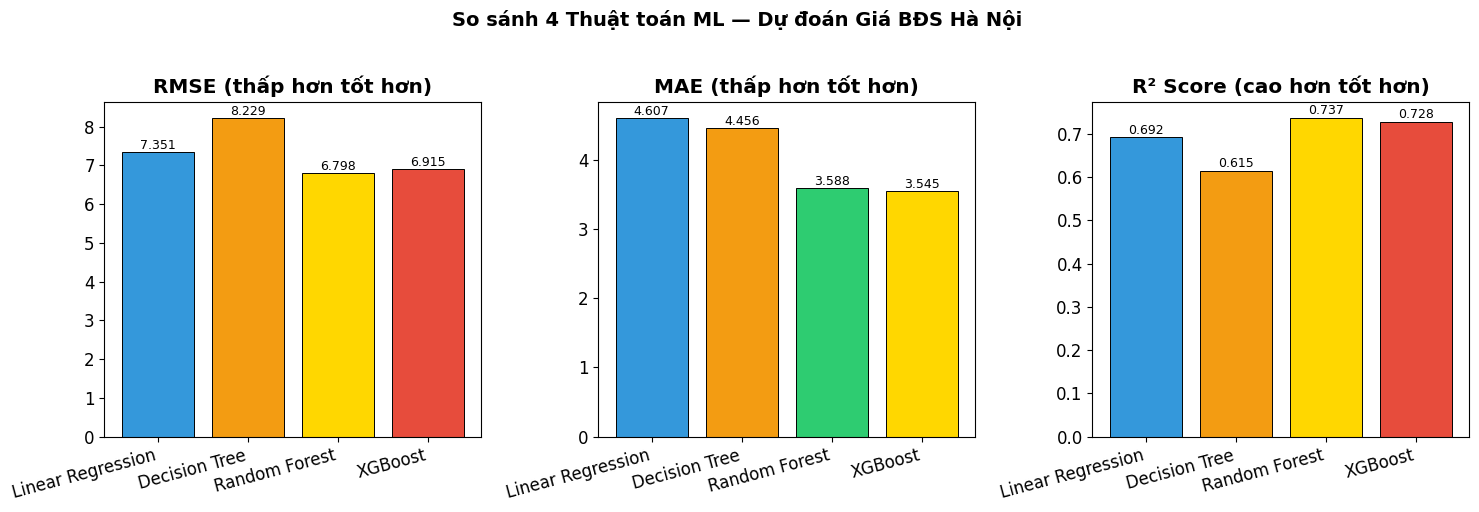

✅ Đã lưu biểu đồ so sánh!


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
names = list(results.keys())
colors = ['#3498db','#f39c12','#2ecc71','#e74c3c']

for ax, metric, title, best_fn in zip(
    axes,
    ['RMSE','MAE','R2'],
    ['RMSE (thấp hơn tốt hơn)','MAE (thấp hơn tốt hơn)','R² Score (cao hơn tốt hơn)'],
    [min, min, max]
):
    vals = [results[n][metric] for n in names]
    best_val = best_fn(vals)
    bar_colors = ['gold' if v == best_val else c for v, c in zip(vals, colors)]
    bars = ax.bar(names, vals, color=bar_colors, edgecolor='black', linewidth=0.7)
    ax.set_title(title, fontweight='bold')
    ax.set_xticklabels(names, rotation=15, ha='right')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('So sánh 4 Thuật toán ML — Dự đoán Giá BĐS Hà Nội', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('./models_hanoi/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Đã lưu biểu đồ so sánh!')

## 9. Xuất Pipeline tốt nhất (.pkl)

In [15]:
os.makedirs('./models_hanoi', exist_ok=True)

best_pipeline = results[best_name]['pipeline']

# Lưu pipeline (bao gồm cả preprocessor + model trong 1 file duy nhất)
with open('./models_hanoi/best_model_pipeline.pkl', 'wb') as f:
    pickle.dump(best_pipeline, f)

# Trích xuất Feature Importance cho XAI (Giải thích AI trên Web)
base_model_best = best_pipeline.named_steps['model']
ohe_cols_best = best_pipeline.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(categorical_features)
all_feat_names = numeric_features + list(ohe_cols_best)
fi_values = base_model_best.feature_importances_
fi_dict = dict(zip(all_feat_names, [float(v) for v in fi_values]))

# Lưu metadata (bao gồm Feature Importance cho XAI)
model_meta = {
    'best_model_name': best_name,
    'features': FEATURES,
    'target': TARGET,
    'numeric_features': numeric_features,
    'categorical_features': categorical_features,
    'metrics': {k: v for k, v in results[best_name].items() if k in ['RMSE','MAE','R2']},
    'all_results': {n: {k: v for k, v in d.items() if k in ['RMSE','MAE','R2']} for n, d in results.items()},
    'feature_importance': fi_dict  # ← THÊM MỚI: Dùng cho XAI trên Web
}
with open('./models_hanoi/model_meta.pkl', 'wb') as f:
    pickle.dump(model_meta, f)

print('✅ Đã xuất các file:')
print('   📁 models/best_model_pipeline.pkl — Pipeline hoàn chỉnh (preprocessor + model)')
print('   📁 models/model_meta.pkl          — Metadata, kết quả & Feature Importance (XAI)')
print('   📁 models/model_comparison.png    — Biểu đồ so sánh')
print(f'\n🏆 Model xuất: {best_name}')
print(f'📊 Feature Importance đã được lưu ({len(fi_dict)} features) → Dùng cho Giải thích AI trên Web')
print(f'\n💡 Lưu ý: Chỉ cần 1 file pipeline.pkl duy nhất để deploy lên Web!')
print(f'   Web chỉ cần gọi: pipeline.predict(raw_dataframe) — không cần encode/scale thủ công.')


✅ Đã xuất các file:
   📁 models/best_model_pipeline.pkl — Pipeline hoàn chỉnh (preprocessor + model)
   📁 models/model_meta.pkl          — Metadata, kết quả & Feature Importance (XAI)
   📁 models/model_comparison.png    — Biểu đồ so sánh

🏆 Model xuất: Random Forest
📊 Feature Importance đã được lưu (40 features) → Dùng cho Giải thích AI trên Web

💡 Lưu ý: Chỉ cần 1 file pipeline.pkl duy nhất để deploy lên Web!
   Web chỉ cần gọi: pipeline.predict(raw_dataframe) — không cần encode/scale thủ công.


## 10. Feature Importance (Random Forest & XGBoost)

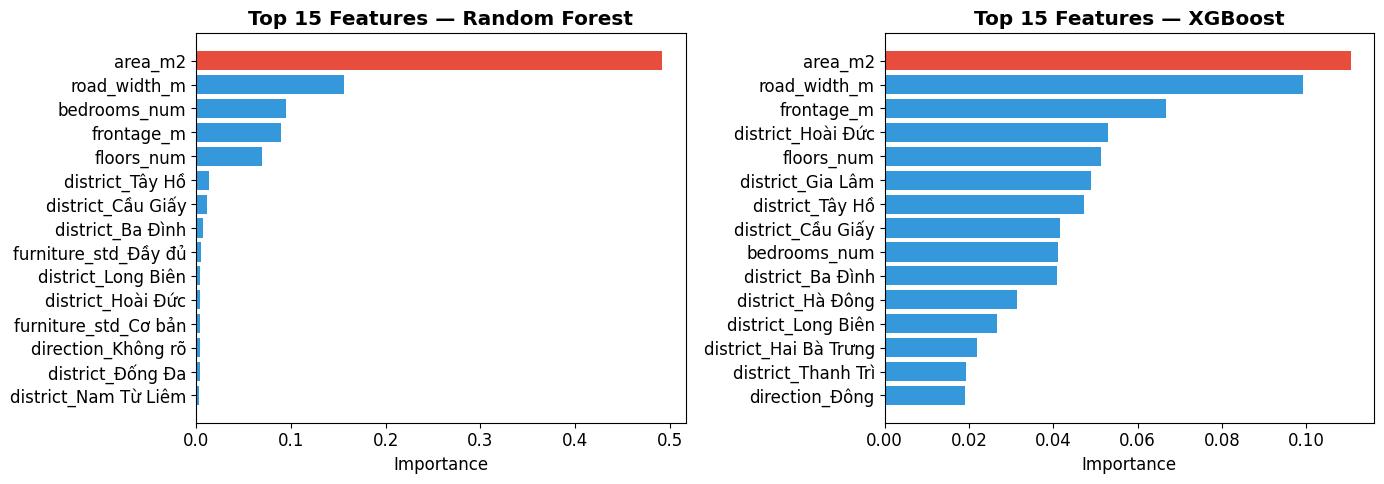

✅ Đã lưu biểu đồ Feature Importance!


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, model_name in [(axes[0], 'Random Forest'), (axes[1], 'XGBoost')]:
    pipeline = results[model_name]['pipeline']
    base_model = pipeline.named_steps['model']
    
    # Lấy feature names sau OneHotEncoder
    ohe_cols = pipeline.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(categorical_features)
    all_features = numeric_features + list(ohe_cols)
    
    fi = base_model.feature_importances_
    fi_df = pd.DataFrame({'feature': all_features, 'importance': fi})\
              .sort_values('importance', ascending=False).head(15)
    fi_df = fi_df.sort_values('importance', ascending=True)
    
    colors_fi = ['#e74c3c' if i == fi_df['importance'].idxmax() else '#3498db'
                 for i in fi_df.index]
    ax.barh(fi_df['feature'], fi_df['importance'], color=colors_fi)
    ax.set_title(f'Top 15 Features — {model_name}', fontweight='bold')
    ax.set_xlabel('Importance')

plt.tight_layout()
plt.savefig('./models_hanoi/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Đã lưu biểu đồ Feature Importance!')

## 11. Test dự đoán nhanh

In [17]:
def predict_price(area_m2, bedrooms, district_name, furniture, legal, loai='chung_cu',
                  floors=0, frontage=0, road_width=0, direction='Không rõ'):
    """
    Dự đoán giá BĐS theo tỷ VNĐ.
    Sử dụng Pipeline nên không cần encode/scale thủ công.
    """
    sample = pd.DataFrame([{
        'area_m2': area_m2, 'bedrooms_num': bedrooms,
        'district': district_name, 'direction': direction,
        'furniture_std': furniture, 'legal_std': legal,
        'floors_num': floors, 'frontage_m': frontage,
        'road_width_m': road_width, 'loai_bds': loai
    }])
    return best_pipeline.predict(sample)[0]

test_cases = [
    ('Chung cư 75m², 2PN, Cầu Giấy, Đầy đủ, Sổ đỏ',
     dict(area_m2=75, bedrooms=2, district_name='Cầu Giấy',
          furniture='Đầy đủ', legal='Sổ đỏ/Sổ hồng', loai='chung_cu')),
    ('Chung cư 50m², 2PN, Hà Đông, Cơ bản, HĐMB',
     dict(area_m2=50, bedrooms=2, district_name='Hà Đông',
          furniture='Cơ bản', legal='HĐMB', loai='chung_cu')),
    ('Nhà đất 45m², 4PN, Thanh Xuân, Đầy đủ, Sổ đỏ, 5 tầng',
     dict(area_m2=45, bedrooms=4, district_name='Thanh Xuân',
          furniture='Đầy đủ', legal='Sổ đỏ/Sổ hồng', loai='nha_dat',
          floors=5, frontage=4.2, road_width=4.0)),
    ('Nhà đất 60m², 3PN, Ba Đình, Đầy đủ, Sổ đỏ, 4 tầng',
     dict(area_m2=60, bedrooms=3, district_name='Ba Đình',
          furniture='Đầy đủ', legal='Sổ đỏ/Sổ hồng', loai='nha_dat',
          floors=4, frontage=4.0, road_width=5.0)),
]

print('🔮 THỬ NGHIỆM DỰ ĐOÁN GIÁ (Hà Nội):')
print('='*60)
for desc, params in test_cases:
    price = predict_price(**params)
    print(f'  📍 {desc}')
    print(f'     → Giá dự đoán: {price:.2f} tỷ VNĐ (~{price*1000:.0f} triệu)\n')

🔮 THỬ NGHIỆM DỰ ĐOÁN GIÁ (Hà Nội):
  📍 Chung cư 75m², 2PN, Cầu Giấy, Đầy đủ, Sổ đỏ
     → Giá dự đoán: 9.28 tỷ VNĐ (~9278 triệu)

  📍 Chung cư 50m², 2PN, Hà Đông, Cơ bản, HĐMB
     → Giá dự đoán: 4.44 tỷ VNĐ (~4439 triệu)

  📍 Nhà đất 45m², 4PN, Thanh Xuân, Đầy đủ, Sổ đỏ, 5 tầng
     → Giá dự đoán: 11.35 tỷ VNĐ (~11355 triệu)

  📍 Nhà đất 60m², 3PN, Ba Đình, Đầy đủ, Sổ đỏ, 4 tầng
     → Giá dự đoán: 11.72 tỷ VNĐ (~11720 triệu)



Bad pipe message: %s [b'\xfb\x0e5e\xb9\xc4\x1a\xf6\xd7\xa8\xf7bR\x15\x85\x15\x9a\xc9 \x91\xaa&\xd0c\x8a~ZPk{\t\x00`\xf4"\xf8\xd1\xe5B\x99\xde.\x01\xe6\xe0gw\x16\x87\xd56\x00$\x13\x01\x13\x02\x13\x03\xc0/\xc0+\xc00\xc0,\xc0\'\xcc\xa9\xcc\xa8\xc0\t\xc0\x13\xc0\n\xc0\x14\x00\x9c\x00\x9d\x00/\x005\x01\x00\x00p\x00\x17\x00\x00\xff\x01\x00\x01\x00\x00\n\x00\x08\x00']
Bad pipe message: %s [b'\x1d\x00\x17\x00\x18']
Bad pipe message: %s [b"\xaf#N\xe7\xcd#>\xf1.\n\x95\x9e\x12\x88\x18\xd7\xe4\xc9 \xc7e\x19]u\x04,3\x11\xf0D\x99\xc5\xd1\x19\x9d~{\x13\xdfs{\xac\xa0\xdf&\xf8sH\x04\xf9+\x00$\x13\x01\x13\x02\x13\x03\xc0/\xc0+\xc00\xc0,\xc0'\xcc\xa9\xcc\xa8\xc0\t\xc0\x13\xc0\n\xc0\x14\x00\x9c\x00\x9d\x00/\x005\x01\x00\x00p\x00\x17\x00\x00\xff\x01\x00\x01\x00\x00\n\x00\x08\x00\x06\x00\x1d"]
ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/Users/tangoctai/Library/Python/3.9/lib/python/site-packages/zmq/eventloop/zmqstream.py", line 565, in _log_err

## ✅ Tổng kết

| File xuất | Mô tả |
|---|---|
| `models/best_model_pipeline.pkl` | Pipeline hoàn chỉnh (Preprocessor + Model) |
| `models/model_meta.pkl` | Metadata, kết quả & **Feature Importance (XAI)** |
| `models/model_comparison.png` | Biểu đồ so sánh 4 thuật toán |
| `models/feature_importance.png` | Feature Importance (Top 15) |

**Ưu điểm Pipeline v2:**
- Chỉ cần **1 file `.pkl` duy nhất** để deploy
- `OneHotEncoder` đúng kỹ thuật cho biến Nominal (quận, hướng, nội thất...)
- `handle_unknown='ignore'` giúp model không crash khi gặp giá trị mới
- Web chỉ cần gọi `pipeline.predict(raw_df)` — không cần encode/scale thủ công
- **Feature Importance** được lưu vào `model_meta.pkl` → Web dùng cho tính năng **Giải thích AI (XAI)**

**Xem chi tiết đánh giá tại: `04_evaluation.ipynb`**
